In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator



import sys
from pathlib import Path

# classifier/ → MELTING_POINT_2026/
PROJECT_ROOT = Path.cwd().parent        # directory above a path: .../MELTING_POINT_2026

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from feature_engineering.feature_engineering_helper import (
    smiles_to_features,
    standardize_features,
    reduce_features_by_variance,

)



In [6]:
processed_dir = PROJECT_ROOT / "data_curation" / "processed_data"

data_path = processed_dir / "data_with_selected_feaatures.parquet"
df = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("Shape:", df.shape)

Loaded: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/data_curation/processed_data/data_with_selected_feaatures.parquet
Shape: (17633, 83)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17633 entries, 0 to 17632
Data columns (total 83 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   SMILES                                         17633 non-null  object 
 1   MP                                             17633 non-null  float64
 2   Type                                           17633 non-null  object 
 3   RDKit_NumRotatableBonds X RDKit_fr_quatN       17633 non-null  int64  
 4   RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5          17630 non-null  float64
 5   RDKit_SlogP_VSA8 X RDKit_fr_bicyclic           17633 non-null  float64
 6   RDKit_TPSA X RDKit_NumHDonors                  17633 non-null  float64
 7   MACCS_156 X MACCS_163                          17633 non-null  int64  
 8   RDKit_SMR_VSA5 X MACCS_39                      17633 non-null  float64
 9   RDKit_Chi0v X MACCS_144                        176

In [12]:
df.isna().any().any()   # If Ture, NaN exists
cols_with_nan = df.columns[df.isna().any()]
cols_with_nan
print (cols_with_nan)

nan_counts = df.isna().sum()
nan_counts[nan_counts > 0].sort_values(ascending=False)

Index(['RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5',
       'RDKit_BCUT2D_CHGLO X MACCS_39', 'RDKit_BCUT2D_CHGLO X RDKit_PEOE_VSA6',
       'RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA12'],
      dtype='object')


RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5     3
RDKit_BCUT2D_CHGLO X MACCS_39             3
RDKit_BCUT2D_CHGLO X RDKit_PEOE_VSA6      3
RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA12    3
dtype: int64

In [17]:
# Removing rows with NaN values

nan_mask = df.isna().any(axis=1)
removed_due_to_nan = df.loc[nan_mask].copy()
df_clean = df.loc[~nan_mask].reset_index(drop=True)

removed_smiles = df.loc[nan_mask, "SMILES"]

print("Removed SMILES due to NaN features:")
for s in removed_smiles:
    print(s)

removed_info = df.loc[nan_mask].copy()

removed_info["NaN_features"] = (
    removed_info.isna()
    .apply(lambda r: list(r[r].index), axis=1)
)

removed_info[["SMILES", "NaN_features"]]


Removed SMILES due to NaN features:
Cc1ccc(cc1)S(=O)(=O)O[I](c1ccccc1)O
[O-]/C(=C\C(=O)C)/C.[O-]/C(=C\C(=O)C)/C.[O-]/C(=C\C(=O)C)/C.[Co+3]
[C-]#[O+]


,SMILES,NaN_features
1840,Cc1ccc(cc1)S(=O)(=O)O[I](c1ccccc1)O,"[RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5, RDKit_..."
10922,[O-]/C(=C\C(=O)C)/C.[O-]/C(=C\C(=O)C)/C.[O-]/C...,"[RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5, RDKit_..."
17014,[C-]#[O+],"[RDKit_BCUT2D_CHGLO X RDKit_SlogP_VSA5, RDKit_..."


In [26]:
from sklearn.preprocessing import StandardScaler
import joblib

feature_cols = [c for c in df_clean.columns if c not in ["SMILES", "Type", "MP"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])

df_scaled = df_clean.copy()
df_scaled[feature_cols] = X_scaled


artifacts_dir = PROJECT_ROOT / "classifier" / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

scaler_path = artifacts_dir / "standard_scaler_featurization.joblib"
joblib.dump(scaler, scaler_path)

print("Scaler saved to:", scaler_path)



Scaler saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/classifier/artifacts/standard_scaler_featurization.joblib


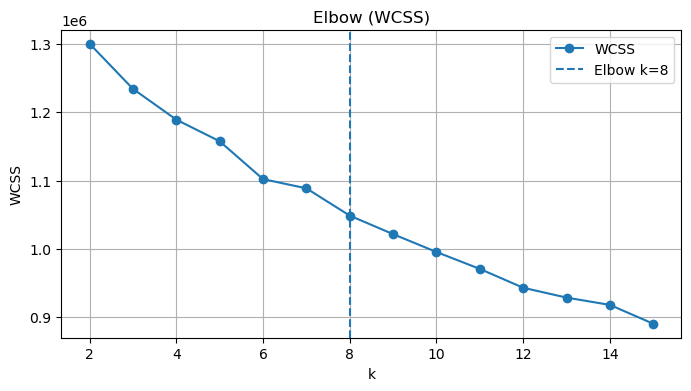

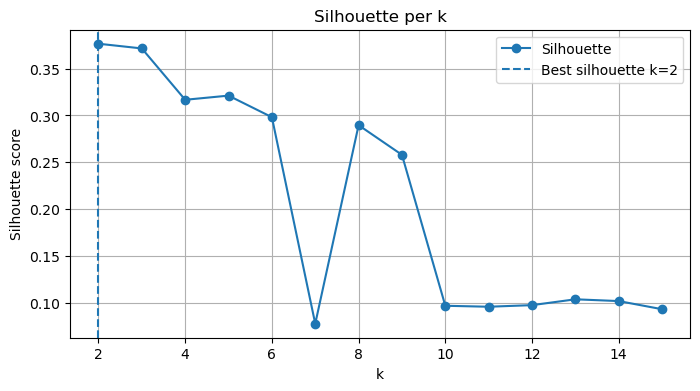

Elbow k: 8 | Best silhouette k: 2 | Selected k_opt: 8

✅ Assigned Structure_Cluster with k=8.
                                              SMILES  Structure_Cluster
0                              CCOC(=O)/C=C/C(=O)OCC                  0
1  O=C(c1ccc(cc1)C(=O)Oc1cc(Cl)cc(c1)Cl)Oc1cc(Cl)...                  4
2  O=C(c1ccccc1)Nc1cccc(c1)/N=N/c1cccc(c1)NC(=O)c...                  2
3                                           C[SiH2]C                  0
4                                     OCc1cccc(n1)CO                  0
✅ Clustered parquet saved to: /Users/sdl5_mp/Documents/GitHub/melting_point_2026/classifier/artifacts/data_with_selected_features_scaled_clustered.parquet


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator


# -----------------------------
# 2) Function: Find optimal k
# -----------------------------
def find_optimal_clusters(X_scaled, max_k=15, random_state=0, plot=True):
    ks = list(range(2, max_k + 1))
    wcss, sils = [], []

    for k in ks:
        km = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=random_state
        )
        labels = km.fit_predict(X_scaled)
        wcss.append(km.inertia_)

        try:
            sils.append(silhouette_score(X_scaled, labels))
        except Exception:
            sils.append(np.nan)

    kn = KneeLocator(ks, wcss, curve="convex", direction="decreasing")
    k_elbow = kn.elbow
    k_sil = ks[int(np.nanargmax(sils))] if np.isfinite(sils).any() else None
    k_opt = k_elbow if k_elbow is not None else k_sil

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, wcss, marker="o", label="WCSS")
        if k_elbow is not None:
            ax.axvline(k_elbow, linestyle="--", label=f"Elbow k={k_elbow}")
        ax.set(xlabel="k", ylabel="WCSS", title="Elbow (WCSS)")
        ax.grid(True); ax.legend()
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(ks, sils, marker="o", label="Silhouette")
        if k_sil is not None:
            ax.axvline(k_sil, linestyle="--", label=f"Best silhouette k={k_sil}")
        ax.set(xlabel="k", ylabel="Silhouette score", title="Silhouette per k")
        ax.grid(True); ax.legend()
        plt.show()

    print(f"Elbow k: {k_elbow} | Best silhouette k: {k_sil} | Selected k_opt: {k_opt}")
    return k_opt

# -----------------------------
# 3) Cluster + attach labels
# -----------------------------
random_state = 0

k_opt = find_optimal_clusters(X_scaled, max_k=15, random_state=random_state, plot=True)
if k_opt is None:
    k_opt = 3
    print("No clear elbow/silhouette; defaulting to k=3.")

final_kmeans = KMeans(
    n_clusters=int(k_opt),
    init="k-means++",
    n_init=10,
    random_state=random_state
)

cluster_labels = final_kmeans.fit_predict(X_scaled)

# sanity check alignment
assert len(cluster_labels) == len(df_scaled), "Cluster labels length != df_scaled rows (mismatch)."

df_clustered = df_scaled.copy()
df_clustered["Structure_Cluster"] = cluster_labels

print(f"\n✅ Assigned Structure_Cluster with k={k_opt}.")
print(df_clustered[["SMILES", "Structure_Cluster"]].head())

# -----------------------------
# 4) Save clustered parquet (+ optional kmeans)
# -----------------------------
clustered_path = artifacts_dir / "data_with_selected_features_scaled_clustered.parquet"
df_clustered.to_parquet(clustered_path, index=False)
print("✅ Clustered parquet saved to:", clustered_path)


In [ ]:
# Remove NaN features



In [ ]:
# Calling the functions